<a href="https://colab.research.google.com/github/Pesse123/workshop_coding/blob/main/FEniCS_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip -q install condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


The following cell intalls FEniCS and set up the environment

In [15]:
%%bash
mamba create -y -n fenicsenv -c conda-forge python=3.10 fenics matplotlib


prefix already exists: /usr/local/envs/fenicsenv

CondaValueError: prefix already exists: /usr/local/envs/fenicsenv



CalledProcessError: Command 'b'mamba create -y -n fenicsenv -c conda-forge python=3.10 fenics matplotlib\n'' returned non-zero exit status 1.

In [ ]:
!conda run -n fenicsenv python -u -c "import dolfin; print('dolfin:', dolfin.__version__); print('hello from fenics')"


dolfin: 2019.1.0
hello from fenics



Steady state heat conduction

In [ ]:
%%bash
export MPLBACKEND=Agg
/usr/local/bin/conda run --no-capture-output -n fenicsenv python -u - <<'PY'
import os, warnings
warnings.filterwarnings('ignore', message='pkg_resources is deprecated*')

from dolfin import *
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

print("Python running. CWD =", os.getcwd())

# -----------------------------
# Mesh and space
# -----------------------------
Lx, Ly = 1.0, 0.2
mesh = RectangleMesh(Point(0.0, 0.0), Point(Lx, Ly), 120, 30)

V = FunctionSpace(mesh, "CG", 1)
T = TrialFunction(V)
v = TestFunction(V)

# -----------------------------
# Material
# -----------------------------
k = Constant(20.0) # W/(m*K)
T_amb = Constant(293.15) # K

# -----------------------------
# Laser flux on top boundary
# -----------------------------
P = 200 # W
eta = 0.6 # absorptivity
r = 0.03 # m (beam radius)
x0 =0.5 # beam center x (steady)
y0 = Ly # on top edge
A = eta * 2.0 * P / (np.pi * r**2) # peak intensity scale

q_laser = -Expression(
    'A*exp(-2.0*((x[0]-x0)*(x[0]-x0) + (x[1]-y0)*(x[1]-y0))/r2)',
    degree=2, A=A, x0=x0, y0=y0, r2=r**2
)

# -----------------------------
# Boundary markers
# -----------------------------
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1, 0)

class Top(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], Ly)

class Bottom(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], 0.0)

top_id, bottom_id = 1, 2
Top().mark(boundaries, top_id)
Bottom().mark(boundaries, bottom_id)
ds = Measure("ds", domain=mesh, subdomain_data=boundaries)

bc = DirichletBC(V, T_amb, boundaries, bottom_id)

# Weak form: ∫ k∇T·∇v dx = -∫ q v ds_top
a = k*dot(grad(T), grad(v))*dx
L = -q_laser*v*ds(top_id)

T_sol = Function(V)
solve(a == L, T_sol, bc)

print("Solved. Tmin/Tmax =", float(T_sol.vector().min()), float(T_sol.vector().max()))

# Plot and save (absolute path!)
out = "/content/steady_temperature.png"
plt.figure(figsize=(7, 2.4))
p = plot(T_sol)
plt.colorbar(p)
plt.title("Steady temperature (laser flux on top)")
plt.tight_layout()
plt.savefig(out, dpi=180)
plt.close()
print("Saved figure to:", out)
PY

# Verify file exists
ls -lh /content/steady_temperature.png || true

Python running. CWD = /content
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
Solved. Tmin/Tmax = 293.15 467.6379897077488
Saved figure to: /content/steady_temperature.png
-rw-r--r-- 1 root root 37K Mar  9 15:45 /content/steady_temperature.png


Transient heat conduction

In [ ]:
%%bash
export MPLBACKEND=Agg
/usr/local/bin/conda run --no-capture-output -n fenicsenv python -u - <<'PY'
import warnings, os
warnings.filterwarnings('ignore', message='pkg_resources is deprecated*')

from dolfin import *
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

print("Generating transient heat video...")

# Output directory for frames
frame_dir = "/content/frames"
os.makedirs(frame_dir, exist_ok=True)

# -----------------------------
# Mesh and space
# -----------------------------
Lx, Ly = 1.0, 0.2
mesh = RectangleMesh(Point(0.0, 0.0), Point(Lx, Ly), 120, 30)
V = FunctionSpace(mesh, "CG", 1)

T = TrialFunction(V)  # unknown at n+1
v = TestFunction(V)

Tn   = Function(V)    # known at n
Tsol = Function(V)    # solution at n+1

# -----------------------------
# Material
# -----------------------------
rho   = Constant(800.0)
c     = Constant(50.0)
k     = Constant(20.0)
T_amb = Constant(293.15)

Tn.assign(interpolate(T_amb, V))  # Initial condition

# -----------------------------
# Boundaries
# -----------------------------
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1, 0)

class Top(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], Ly)

class Left(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0)

class Right(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], Lx)

class Bottom(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], 0.0)

top_id, bottom_id = 1, 2
left_id=3
right_id=4
Top().mark(boundaries, top_id)
Bottom().mark(boundaries, bottom_id)
Left().mark(boundaries, 3)
Right().mark(boundaries, 4)
ds = Measure("ds", domain=mesh, subdomain_data=boundaries)

# Dirichlet BC on bottom
bc = DirichletBC(V, T_amb, boundaries, bottom_id)

# -----------------------------
# Moving laser flux on top
# -----------------------------
P, eta, r = 200.0, 0.6, 0.03
A = float(eta * 2.0 * P / (np.pi * r**2))

x_start, v_scan = 0.2, 0.4
y0 = float(Ly)

q_laser = Expression(
    '-A*exp(-2.0*((x[0]-x0)*(x[0]-x0) + (x[1]-y0)*(x[1]-y0))/r2)',
    degree=2, A=A, x0=x_start, y0=y0, r2=r**2
)

# -----------------------------
# Time stepping
# -----------------------------
dt    = 1e-3
t_end = 0.8
dt_c  = Constant(dt)

# Weak form (implicit Euler)
a = (rho*c/dt_c)*T*v*dx + k*dot(grad(T), grad(v))*dx
L = (rho*c/dt_c)*Tn*v*dx - q_laser*v*ds(top_id)

t = 0.0
step = 0
frame_id = 0

while t < t_end - 1e-12:
    t += dt
    step += 1

    # update laser position
    q_laser.x0 = x_start + v_scan*t

    solve(a == L, Tsol, bc)
    Tn.assign(Tsol)

    # Save frame every N steps
    if step % 10 == 0:
        plt.figure(figsize=(7, 2.4))
        p = plot(Tsol)
        plt.colorbar(p)
        plt.title(f"t = {t:.3f} s")
        plt.tight_layout()
        fname = f"{frame_dir}/frame_{frame_id:04d}.png"
        plt.savefig(fname, dpi=150)
        plt.close()
        frame_id += 1

print("Frames generated:", frame_id)

# Save final snapshot (THIS MUST BE INSIDE PYTHON)
out = "/content/transient_temperature.png"
plt.figure(figsize=(7, 2.4))
p = plot(Tsol)
plt.colorbar(p)
plt.title("Transient temperature (moving laser flux on top)")
plt.tight_layout()
plt.savefig(out, dpi=180)
plt.close()
print("Saved final snapshot:", out)
PY

# -----------------------------
# Assemble frames into MP4 (bash)
# -----------------------------
ffmpeg -y -framerate 15 -i /content/frames/frame_%04d.png \
       -c:v libx264 -pix_fmt yuv420p /content/transient_heat.mp4

ls -lh /content/transient_heat.mp4 /content/transient_temperature.png || true

Generating transient heat video...
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational pr

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

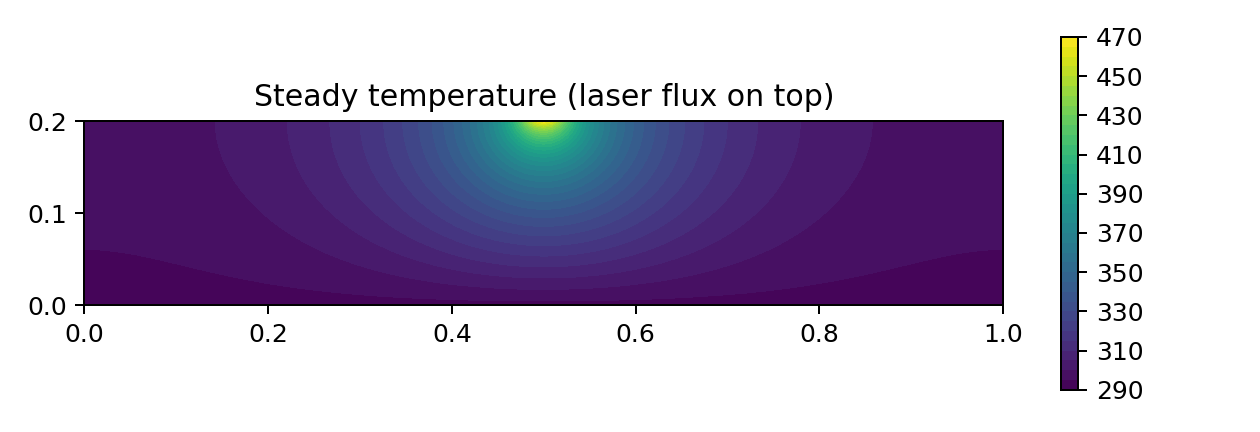

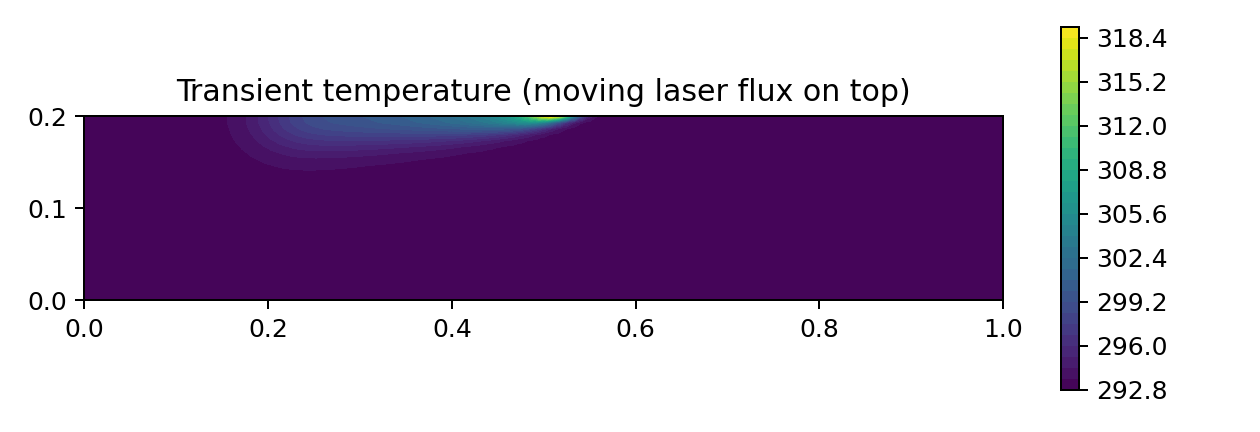

In [ ]:
from IPython.display import Image, display
display(Image("steady_temperature.png"))
display(Image("transient_temperature.png"))

In [ ]:
%%bash
export MPLBACKEND=Agg
/usr/local/bin/conda run --no-capture-output -n fenicsenv python -u - <<'PY'
import os, warnings
warnings.filterwarnings('ignore', message='pkg_resources is deprecated*')

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from dolfin import *

print("Running steady thermo -> mechanical (staggered, fixed)...")

# -----------------------------------------------------------------------------
# 1) Mesh
# -----------------------------------------------------------------------------
L = 0.1
nx, ny = 160, 160
mesh = RectangleMesh(Point(0.0, 0.0), Point(L, L), nx, ny)

mesh_png = "/content/mesh.png"
plt.figure(figsize=(4.4, 4.2))
plot(mesh)
plt.title("Finite Element Mesh")
plt.axis("equal")
plt.tight_layout()
plt.savefig(mesh_png, dpi=180)
plt.close()
print("Saved:", mesh_png)

# -----------------------------------------------------------------------------
# 2) Boundary markers
# -----------------------------------------------------------------------------
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1, 0)

class Bottom(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], 0.0)

class Top(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], L)

class Left(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0)

bottom_id, top_id, left_id = 1, 2, 3
Bottom().mark(boundaries, bottom_id)
Top().mark(boundaries, top_id)
Left().mark(boundaries, left_id)
ds = Measure("ds", domain=mesh, subdomain_data=boundaries)

# -----------------------------------------------------------------------------
# 3) Thermal (steady conduction)
#    -div(k grad Theta) = 0
#    Theta = T0 on bottom
#    -k grad Theta·n = q_flux on top (q_flux>0 means heating into body)
# -----------------------------------------------------------------------------
T0 = Constant(293.0)

Vt = FunctionSpace(mesh, "CG", 1)
Theta = TrialFunction(Vt)
psi   = TestFunction(Vt)

# Keep your "proxy" k(x) demo
class ThermalConductivity(UserExpression):
    def eval(self, values, x):
        Tproxy = x[1]
        values[0] = 30.0 - 0.02*(Tproxy - 293.0)
    def value_shape(self): return ()

k = ThermalConductivity(degree=1)

# Make flux POSITIVE for heating
class GaussianHeatFlux(UserExpression):
    def eval(self, values, x):
        values[0] = 2e6*np.exp(-1e5*(x[0] - 0.5*L)**2)   # <-- positive heating
    def value_shape(self): return ()

q_flux = GaussianHeatFlux(degree=2)

bc_T_bottom = DirichletBC(Vt, T0, boundaries, bottom_id)

aT = inner(k*grad(Theta), grad(psi))*dx
LT = q_flux*psi*ds(top_id)

Theta_sol = Function(Vt)
solve(aT == LT, Theta_sol, bc_T_bottom)

print("Thermal solved. Theta min/max =", float(Theta_sol.vector().min()), float(Theta_sol.vector().max()))

temp_png = "/content/temperature.png"
plt.figure(figsize=(5.4, 4.2))
p = plot(Theta_sol)
plt.colorbar(p)
plt.title("Temperature (steady, heating on top)")
plt.axis("equal")
plt.tight_layout()
plt.savefig(temp_png, dpi=180)
plt.close()
print("Saved:", temp_png)

# -----------------------------------------------------------------------------
# 4) Mechanical (linear elasticity with thermal strain as RHS load)
#    div(sigma) = 0
#    sigma = sigma_mech(u) - kappa(Theta - T0) I
#    => ∫ sigma_mech(u):eps(v) dx = ∫ kappa(Theta-T0) I : eps(v) dx
# -----------------------------------------------------------------------------
Vu = VectorFunctionSpace(mesh, "CG", 2)
u = TrialFunction(Vu)
v = TestFunction(Vu)

E  = Constant(3.70e11)
nu = Constant(0.22)
lmbda = E*nu/((1+nu)*(1-2*nu))
mu    = E/(2*(1+nu))

alpha = Constant(8e-6)  # keep constant for linear teaching demo
kappa = alpha*(2.0*mu + 3.0*lmbda)

def eps(w):
    return sym(grad(w))

def sigma_mech(w):
    return lmbda*tr(eps(w))*Identity(2) + 2.0*mu*eps(w)

# --- Pointwise anchor at left-bottom corner (0,0): ux=uy=0
def left_bottom_point(x, on_boundary):
    return on_boundary and near(x[0], 0.0, 1e-12) and near(x[1], 0.0, 1e-12)

bc_u_anchor = DirichletBC(Vu, Constant((0.0, 0.0)),
                          left_bottom_point, method="pointwise")

# --- One extra scalar constraint to remove rigid rotation:
#     Fix uy = 0 at (L,0) (right-bottom point)
def right_bottom_point(x, on_boundary):
    return on_boundary and near(x[0], L, 1e-12) and near(x[1], 0.0, 1e-12)

bc_u_no_rotation = DirichletBC(Vu.sub(1), Constant(0.0),
                               right_bottom_point, method="pointwise")

bcs_u = [bc_u_anchor, bc_u_no_rotation]

# Fix left boundary to remove rigid body motion
bc_u_left = DirichletBC(Vu, Constant((0.0, 0.0)), boundaries, left_id)

# Bilinear (depends on u)
aU = inner(sigma_mech(u), eps(v))*dx

# Linear: thermal load (depends on known Theta_sol)
LU = inner(kappa*(Theta_sol - T0)*Identity(2), eps(v))*dx

u_sol = Function(Vu)
solve(aU == LU, u_sol, bcs_u)
# solve(aU == LU, u_sol, bc_u_left)

print("Mechanical solved. u L-infty =", float(u_sol.vector().norm("linf")))

# -----------------------------------------------------------------------------
# 5) Von Mises stress
# -----------------------------------------------------------------------------
def sigma_total(u_field, Theta_field):
    return sigma_mech(u_field) - kappa*(Theta_field - T0)*Identity(2)

def von_mises(sig):
    s = sig - (1.0/3.0)*tr(sig)*Identity(2)
    return sqrt(3.0/2.0*inner(s, s))

Vm = FunctionSpace(mesh, "CG", 1)
vm = project(von_mises(sigma_total(u_sol, Theta_sol)), Vm)

vm_png = "/content/von_mises.png"
plt.figure(figsize=(5.4, 4.2))
p = plot(vm)
plt.colorbar(p)
plt.title("Von Mises Stress (thermoelastic)")
plt.axis("equal")
plt.tight_layout()
plt.savefig(vm_png, dpi=180)
plt.close()
print("Saved:", vm_png)

PY

ls -lh /content/mesh.png /content/temperature.png /content/von_mises.png || true

Running steady thermo -> mechanical (staggered, fixed)...
Saved: /content/mesh.png
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
Thermal solved. Theta min/max = 293.0 862.9470612976586
Saved: /content/temperature.png
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
Mechanical solved. u L-infty = 0.0001533542854350956
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, thi

In [ ]:
%%bash
export MPLBACKEND=Agg
/usr/local/bin/conda run --no-capture-output -n fenicsenv python -u - <<'PY'
import os, warnings
warnings.filterwarnings('ignore', message='pkg_resources is deprecated*')

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from dolfin import *

print("Running steady thermo->mechanical with Picard loop (teaching demo)...")

# -----------------------------------------------------------------------------
# 1) Mesh
# -----------------------------------------------------------------------------
L = 0.1
nx, ny = 160, 160
mesh = RectangleMesh(Point(0.0, 0.0), Point(L, L), nx, ny)

# -----------------------------------------------------------------------------
# 2) Boundary markers
# -----------------------------------------------------------------------------
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1, 0)

class Bottom(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], 0.0)

class Top(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], L)

bottom_id, top_id = 1, 2
Bottom().mark(boundaries, bottom_id)
Top().mark(boundaries, top_id)
ds = Measure("ds", domain=mesh, subdomain_data=boundaries)

# -----------------------------------------------------------------------------
# 3) Thermal space and data
# -----------------------------------------------------------------------------
T0 = Constant(293.0)

Vt = FunctionSpace(mesh, "CG", 1)
Theta = TrialFunction(Vt)
psi   = TestFunction(Vt)

# Conductivity (keep constant for clean teaching; can change to Expression if desired)
k_const = Constant(30.0)

# Heat flux on top: q>0 means heating into body for -k gradT·n = q
class GaussianHeatFlux(UserExpression):
    def eval(self, values, x):
        values[0] = 2e6*np.exp(-1e5*(x[0] - 0.5*L)**2)
    def value_shape(self): return ()
q_flux = GaussianHeatFlux(degree=2)

bc_T_bottom = DirichletBC(Vt, T0, boundaries, bottom_id)

# -----------------------------------------------------------------------------
# 4) Mechanical space and constants
# -----------------------------------------------------------------------------
Vu = VectorFunctionSpace(mesh, "CG", 2)
u = TrialFunction(Vu)
v = TestFunction(Vu)

E  = Constant(3.70e11)
nu = Constant(0.22)
lmbda = E*nu/((1+nu)*(1-2*nu))
mu    = E/(2*(1+nu))

def eps(w):
    return sym(grad(w))

def sigma_mech(w):
    return lmbda*tr(eps(w))*Identity(2) + 2.0*mu*eps(w)

# Point constraints: fix left-bottom point and one extra scalar DOF to remove rotation
def left_bottom_point(x, on_boundary):
    return on_boundary and near(x[0], 0.0, 1e-12) and near(x[1], 0.0, 1e-12)

def right_bottom_point(x, on_boundary):
    return on_boundary and near(x[0], L, 1e-12) and near(x[1], 0.0, 1e-12)

bc_u_anchor = DirichletBC(Vu, Constant((0.0, 0.0)), left_bottom_point, method="pointwise")
bc_u_no_rot = DirichletBC(Vu.sub(1), Constant(0.0), right_bottom_point, method="pointwise")
bcs_u = [bc_u_anchor, bc_u_no_rot]

# -----------------------------------------------------------------------------
# 5) Helpers: von Mises for teaching feedback / plotting
# -----------------------------------------------------------------------------
def sigma_total(u_field, Theta_field, kappa_field):
    # sigma = sigma_mech(u) - kappa(Theta) * (Theta - T0) I
    return sigma_mech(u_field) - kappa_field*(Theta_field - T0)*Identity(2)

def von_mises(sig):
    s = sig - (1.0/3.0)*tr(sig)*Identity(2)
    return sqrt(3.0/2.0*inner(s, s))

Vm = FunctionSpace(mesh, "CG", 1)

# -----------------------------------------------------------------------------
# 6) Picard controls (teaching)
# -----------------------------------------------------------------------------
max_it      = 30
rtol        = 1e-6
under_relax = 1.0   # try 0.7 if oscillatory

# "Artificial coupling" strength for teaching:
# If beta=0, thermal is independent of mechanics => Picard will converge immediately.
beta = Constant(0.0)  # set e.g. Constant(1e-5) to demonstrate feedback coupling

# -----------------------------------------------------------------------------
# 7) Initial guess Theta_k: solve baseline steady conduction once
# -----------------------------------------------------------------------------
# Baseline thermal solve: ∫ k ∇Θ·∇ψ = ∫ q ψ ds
aT_base = inner(k_const*grad(Theta), grad(psi))*dx
LT_base = q_flux*psi*ds(top_id)

Theta_k = Function(Vt)
solve(aT_base == LT_base, Theta_k, bc_T_bottom)

print("Initial Theta_k min/max =", float(Theta_k.vector().min()), float(Theta_k.vector().max()))

# -----------------------------------------------------------------------------
# 8) Picard loop
#    We make alpha temperature-dependent (teaching), hence kappa(Theta_k) updates.
# -----------------------------------------------------------------------------
converged = False
u_sol = Function(Vu)

for it in range(1, max_it+1):

    # Temperature-dependent alpha(Theta_k): alpha = a0 + a1*(Theta_k - T0)
    # (teaching; small slope so it stays stable)
    a0 = Constant(8e-6)
    a1 = Constant(1.5e-9)
    alpha_k = a0 + a1*(Theta_k - T0)

    # kappa(Theta_k) = (3 lambda + 2 mu) * alpha(Theta_k)
    kappa_k = (3.0*lmbda + 2.0*mu)*alpha_k

    # --- Mechanical solve with frozen Theta_k and kappa_k ---
    aU = inner(sigma_mech(u), eps(v))*dx
    LU = inner(kappa_k*(Theta_k - T0)*Identity(2), eps(v))*dx

    solve(aU == LU, u_sol, bcs_u)

    # --- Build a "feedback" source from mechanics (optional teaching coupling) ---
    # vm(u,Theta) computed for visualization and optional thermal source term
    vm_k = project(von_mises(sigma_total(u_sol, Theta_k, kappa_k)), Vm)

    # --- Thermal update (Picard): solve for Theta_new using (optional) source beta*vm_k ---
    # Strong form demo: -div(k grad Theta_new) = beta*vm_k  with same BCs
    # Weak form: ∫ k ∇Θ_new·∇ψ = ∫ q ψ ds + ∫ beta*vm_k * ψ dx
    Theta_new = Function(Vt)
    aT = inner(k_const*grad(Theta), grad(psi))*dx
    LT = q_flux*psi*ds(top_id) + beta*vm_k*psi*dx

    solve(aT == LT, Theta_new, bc_T_bottom)

    # --- Convergence check on Theta ---
    num = norm(Theta_new.vector() - Theta_k.vector(), "l2")
    den = max(1.0, norm(Theta_new.vector(), "l2"))
    rel = num/den
    print(f"[Picard] iter {it:02d}: rel_change(Theta) = {rel:.3e}")

    if rel < rtol:
        converged = True
        Theta_k.assign(Theta_new)
        break

    # Under-relaxation
    if under_relax < 1.0:
        v_old = Theta_k.vector().get_local()
        v_new = Theta_new.vector().get_local()
        Theta_k.vector().set_local(under_relax*v_new + (1.0-under_relax)*v_old)
        Theta_k.vector().apply("insert")
    else:
        Theta_k.assign(Theta_new)

if not converged:
    print("WARNING: Picard did not reach requested tolerance.")
else:
    print("Picard converged.")

Theta_sol = Theta_k

# -----------------------------------------------------------------------------
# 9) Final postprocess plots (save to /content)
# -----------------------------------------------------------------------------
# Temperature
temp_png = "/content/picard_temperature.png"
plt.figure(figsize=(5.4, 4.2))
p = plot(Theta_sol)
plt.colorbar(p)
plt.title("Temperature (Picard final)")
plt.axis("equal")
plt.tight_layout()
plt.savefig(temp_png, dpi=180)
plt.close()
print("Saved:", temp_png)

# Recompute final kappa for final stress plot
a0 = Constant(8e-6)
a1 = Constant(1.5e-9)
alpha_final = a0 + a1*(Theta_sol - T0)
kappa_final = (3.0*lmbda + 2.0*mu)*alpha_final

# Final von Mises
vm_final = project(von_mises(sigma_total(u_sol, Theta_sol, kappa_final)), Vm)
vm_png = "/content/picard_von_mises.png"
plt.figure(figsize=(5.4, 4.2))
p = plot(vm_final)
plt.colorbar(p)
plt.title("Von Mises Stress (Picard final)")
plt.axis("equal")
plt.tight_layout()
plt.savefig(vm_png, dpi=180)
plt.close()
print("Saved:", vm_png)

PY

ls -lh /content/picard_temperature.png /content/picard_von_mises.png || true


Running steady thermo->mechanical with Picard loop (teaching demo)...
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
Initial Theta_k min/max = 293.0 974.249923047671
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
[Picard] iter 01: rel_change(Theta) = 0.000e+00
Picard converged.
Saved: /content/picard_temperature.png
Saved: /content/picard_von_mises.png
-rw-r--r-- 1 root root 41K Mar  4 02:09 /content/picard_temperature.png
-rw-r--r-- 1 root root 55K Mar  4 02:09 /content/picard_von_mises.png
